# 회귀및분류모델실습

# 0. 라이브러리 불러오기

In [ ]:
# PyTorch 핵심 라이브러리
import torch
import torch.nn as nn   # 신경망 모델
import torch.optim as optim   # 최적화 알고리즘

# 데이터셋 분리, 평가 지표 사용
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# 데이터 전처리용
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 실습용 데이터셋
import seaborn as sns

# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt

# 실행 장치 설정
# gpu가 있으면 cuda, 없으면 cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치: ', device)

사용 장치:  cpu


## 1. PyTorch 회귀 모델 실습<br>
데이터셋 : tips<br>
목표: total_bill 값을 이용하여 tip 예측

In [ ]:
tips = sns.load_dataset('tips')
# 처음에는 데이터를 pandas의 DataFrame 형식으로 불러온다.

print(tips.head())
print(tips.info())
print(tips.describe())

x = tips[['total_bill']].values     # 변수 값. input 값
y = tips[['tip']].values           # 목표 값. output 값
# values를 통해 pandas 형식으로 저장된 데이터가 numpy배열로 데이터 형식 변화

# 학습 데이터와 테스트 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
    )

# 입력 데이터 스케일링 (x, y 모두) ScaleScaler
x_scaler = StandardScaler()
x_train_scaler = x_scaler.fit_transform(x_train)
x_test_scaler = x_scaler.transform(x_test)

y_scaler = StandardScaler()
y_train_scaler = y_scaler.fit_transform(y_train)
y_test_scaler = y_scaler.transform(y_test)

# numpy 배열을 pytorch tensor로 변환
x_train_tensor = torch.tensor(x_train_scaler, dtype=torch.float32).to(device)
x_test_tensor = torch.tensor(x_test_scaler, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaler, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaler, dtype=torch.float32).to(device)

print('x_train_tensor: ', x_train_tensor.shape)
print('x_test_tensor: ', x_test_tensor.shape)
print('y_train_tensor: ', y_train_tensor.shape)
print('y_train_tensor: ', y_test_tensor.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672


## 2. 회귀 모델 클래스 정의

In [ ]:
class RegressionModel(nn.Module):
  ## nn.Module은 PyTorch에서 모든 신경망 모델의 기본 부모 클래스
  # init에서 제료를 준비하고, forward에서 이 재료를 어떻게 쓸지 정의
  def __init__(self):
    # 부모 클래스 nn.Module의 초기화 기능 실행
    super().__init__()

    # 입력 1개(total_bill)를 받아 출력 1개 (tip)를 예측하는 선형 계층
    self.linear = nn.Linear(1, 1)     # y = wx + b  : w=가중치, b=편향을 무작위로 던진다
                                      # 지금부터 할 일은 w와 b 값을 최적화 하는 것.

  def forward(self, x):
    # 입력 x 가 선형 계층을 통과하여 예측값을 만든다. 순전파
    return self.linear(x)

# 회귀 모델 객체 생성 후 GPU 또는 CPU로 이동
reg_model = RegressionModel().to(device)

# 손실 함수 설정
# Mean Square Error는 예측값과 실제값의 차이를 제곱하여 평균을 나타내는 지표
# 모델이 얼마나 엉터리로 예측했는지 알려주는 나침반
# 모델은 loss를 최소화 하도록 계산한다.
criterion = nn.MSELoss()  # ()를 붙여줘 객체(인스턴스)로 생성해야 함.

# 최적화 알고리즘 설정
# Adam은 학습률을 자동 조절하는 대표적인 최적화 알고리즘
#   경사 하강법(SGD)는 경사가 가파른 쪽으로 일정한 보폭으로 내려간다면
# reg_model.parameters(): 옵티마이저가 수정해야 할 파라미터는 w, b를 알려 줌
# lr: 학습률. 한 걸음의 크기.
optimizer = optim.Adam(reg_model.parameters(), lr=0.01)


print(reg_model)      # RegressionModel((linear): Linear(in_features=1, out_features=1, bias=True))
print(criterion)      # <class 'torch.nn.modules.loss.MSELoss'>
print(optimizer)
"""Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0 )"""

RegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
MSELoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


'Adam (\nParameter Group 0\n    amsgrad: False\n    betas: (0.9, 0.999)\n    capturable: False\n    decoupled_weight_decay: False\n    differentiable: False\n    eps: 1e-08\n    foreach: None\n    fused: None\n    lr: 0.01\n    maximize: False\n    weight_decay: 0 )'

## 3. 회귀 모델 학습

Epochs [100/500], loss:  0.620501
Epochs [200/500], loss:  0.569192
Epochs [300/500], loss:  0.569049
Epochs [400/500], loss:  0.569049
Epochs [500/500], loss:  0.569049


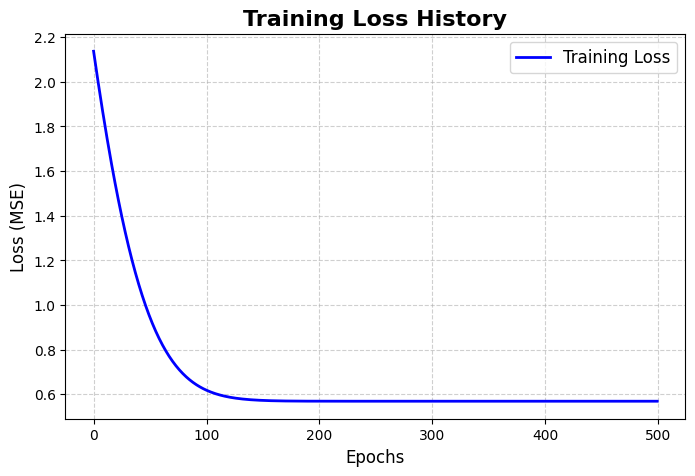

In [ ]:
# 전체 학습 반복 횟수
epochs = 500

# 학습 손실값을 저장할 리스트
loss_history = []

for each in range(epochs):
  # 모델을 학습 모드로 설정
  reg_model.train()

  # 이전 반복에서 계산된 기울기 초기화
  # PyTorch는 미분값 계산할 때 이전 값을 버리지 않고 계속 더하는 성질이 있기 때문
  optimizer.zero_grad()

  # 모델 예측값 계산
  y_pred = reg_model(x_train_tensor)

  # 예측값과 실제값 사이의 손실 예산
  loss = criterion(y_pred, y_train_tensor)

  # 역전파 수행
  # 손실을 줄일려면 각 파라미터를 어느 방향으로 얼마나 수정해야 하는지 계산
  # 각 가중치가 손실에 얼마나 영향을 주었는지 기울기 계산
  loss.backward()

  # 계산된 기울기를 바탕으로 가중치 업데이트
  optimizer.step()

  # 손실값 저장
  loss_history.append(loss.item())

  # 100번마다 학습 상태 출력
  if (each + 1) % 100 == 0:
    print(f'Epochs [{each+1}/{epochs}], loss: {loss.item(): .6f}')


plt.figure(figsize=(8, 5))

# loss_history 리스트를 선 그래프로 그리기
plt.plot(loss_history, label='Training Loss', color='blue', linewidth=2)

# 그래프 제목 및 축 이름 설정 (한글 깨짐 방지를 위해 영어 권장)
plt.title('Training Loss History', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)

# 그리드(격자) 및 범례 추가
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# 그래프 출력
plt.show()


## 4. 회귀 모델 평가

In [ ]:
# 평가 모드로 변경
# 모델은 파라미터를 업데이트 하지 않고 고정된 채로 예측만 수행
reg_model.eval()

# 평가 시에는 기울기 계산 필요 없으므로 no_grad 사용
# 지금부터 미분계산을 위한 추적 하지 마라고 명령
with torch.no_grad():
  # 테스트 데이터 예측
  y_pred_scaled = reg_model(x_test_tensor)

# 머신러닝할 때 스케일 다운한걸 최종 성적표 볼 때 다시 원상복구 필요
# tensor를 Numpy배열로 변환
y_pred_scaled_np = y_pred_scaled.cpu().numpy()
# 스케일링 된 예측값을 원래 tip 단위로 복원
y_pred_original = y_scaler.inverse_transform(y_pred_scaled_np)

# 실제 y_test도 원래 단위로 사용
y_test_original = y_test

# 평균제곱오차 계산
mse = mean_squared_error(y_test_original, y_pred_original)

# 결정계수 계산(Coefficient of Determination)
# 데이터의 분산(변동성)을 얼마나 잘 설명하는지 나타내는 지표
# 1.0 = 완벽한 모델
r2 = r2_score(y_test_original, y_pred_original)

print('MSE: ', mse)
print('r2 score: ', r2)


MSE:  0.5688141922815689
r2 score:  0.5449382144376864


## 5. 회귀 결과 시각화

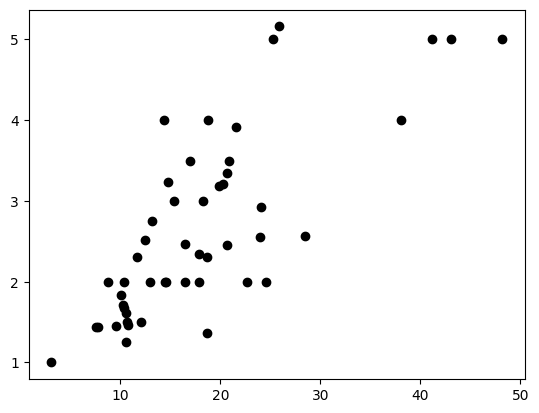

In [ ]:
# 산점도: 실제 데이터
plt.scatter(x_test, y_test_original, color='black', label='Actual')

# 선 그래프
sorted_index = np.argsort(x_test.flatten())

# 정렬된 x_test
x_test_sorted = x_test[sorted_index]

# 정렬된 예측값
y_pred_sorted = y_pred_original[sorted_index]
plt.show()
# 예측 회귀선 출력


